# Datasets Overview

Attribute summary for all spatial proteomics datasets used in this project.
All numbers are derived live from the dataset objects.

**Patients** = unique patients in the loaded data.

**TNBC overlap:** Keren and Patwa profile the *same patients and the same MIBI images*
(Patwa re-analyzes Keren's cohort). The **Total** row is the naive sum across all four
datasets; the **Unique Total** row counts the TNBC cohort once — using Patwa as the
representative (superset) and excluding Keren — so it is the correct distinct count.
Patwa is the primary TNBC dataset; Keren is retained as an out-of-distribution validation set.

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
_r = next(p for p in [Path().resolve(), *Path().resolve().parents] if (p / "data").is_dir() and (p / "notebooks").is_dir())
if str(_r) not in sys.path: sys.path.insert(0, str(_r))

import anndata as ad
import numpy as np

from data.EDA import (
    KEREN_CFG, SCHURCH_CFG, PATWA_CFG, JACKSON_CFG,
    JACKSON_ZURICH_CFG, JACKSON_BASEL_CFG,
    dataset_stats, overview_table,
    normalize_panel, normalize_celltypes, panel_heatmap,
)

In [2]:
DATASETS = [
    ("TNBC (Keren 2018)",                     "../../../data/keren2018/tnbc.h5ad",               KEREN_CFG),
    ("CRC (Schürch 2020)",                    "../../../data/schurch2020/crc.h5ad",              SCHURCH_CFG),
    ("TNBC (Patwa 2021)",                     "../../../data/rasp-mibi/tnbc_mibi.h5ad",          PATWA_CFG),
    ("Breast Cancer (Jackson & Fischer 2020)","../../../data/jacksonfischer2020/full/full.h5ad", JACKSON_CFG),
]

stats, panels, celltypes = [], {}, {}
for name, path, cfg in DATASETS:
    adata = ad.read_h5ad(path, backed="r")
    s = dataset_stats(adata, cfg)
    s["publication"] = name
    stats.append(s)
    panels[name] = normalize_panel(adata.var_names)
    col = cfg.get("celltype_col")
    if col and col in adata.obs.columns:
        celltypes[name] = normalize_celltypes(adata.obs[col])
    adata.file.close()

In [3]:
# Keren ⊂ Patwa (same patients/images) → "Unique Total" counts the TNBC cohort once,
# using Patwa as the representative and excluding Keren from the sums.
overview_table(stats, unique_exclude=["TNBC (Keren 2018)"])

Publication,Technology,Disease,Condition,Patients,Samples,Cells,Markers
TNBC (Keren 2018),MIBI,TNBC,Compartmentalized / Mixed,34,34,"173,205",36
CRC (Schürch 2020),CODEX,CRC,CLR / DII,35,70,"258,385",57
TNBC (Patwa 2021),MIBI,TNBC,Cold / Compartmentalized / Mixed,38,38,"190,240",36
Breast Cancer (Jackson & Fischer 2020),IMC,Breast Cancer,HR+HER2+ / HR+HER2- / HR-HER2+ / TripleNeg,285,723,"1,240,267",37
Total,,,,392,865,"1,862,097",
Unique Total,,,,358,831,"1,688,892",


## Protein Panel Coverage

Binary presence matrix across all four datasets after canonical name normalization
(`PANEL_ALIASES`). Technical/elemental channels excluded. Count on right = number
of datasets sharing each marker. Rows sorted top → bottom by prevalence.

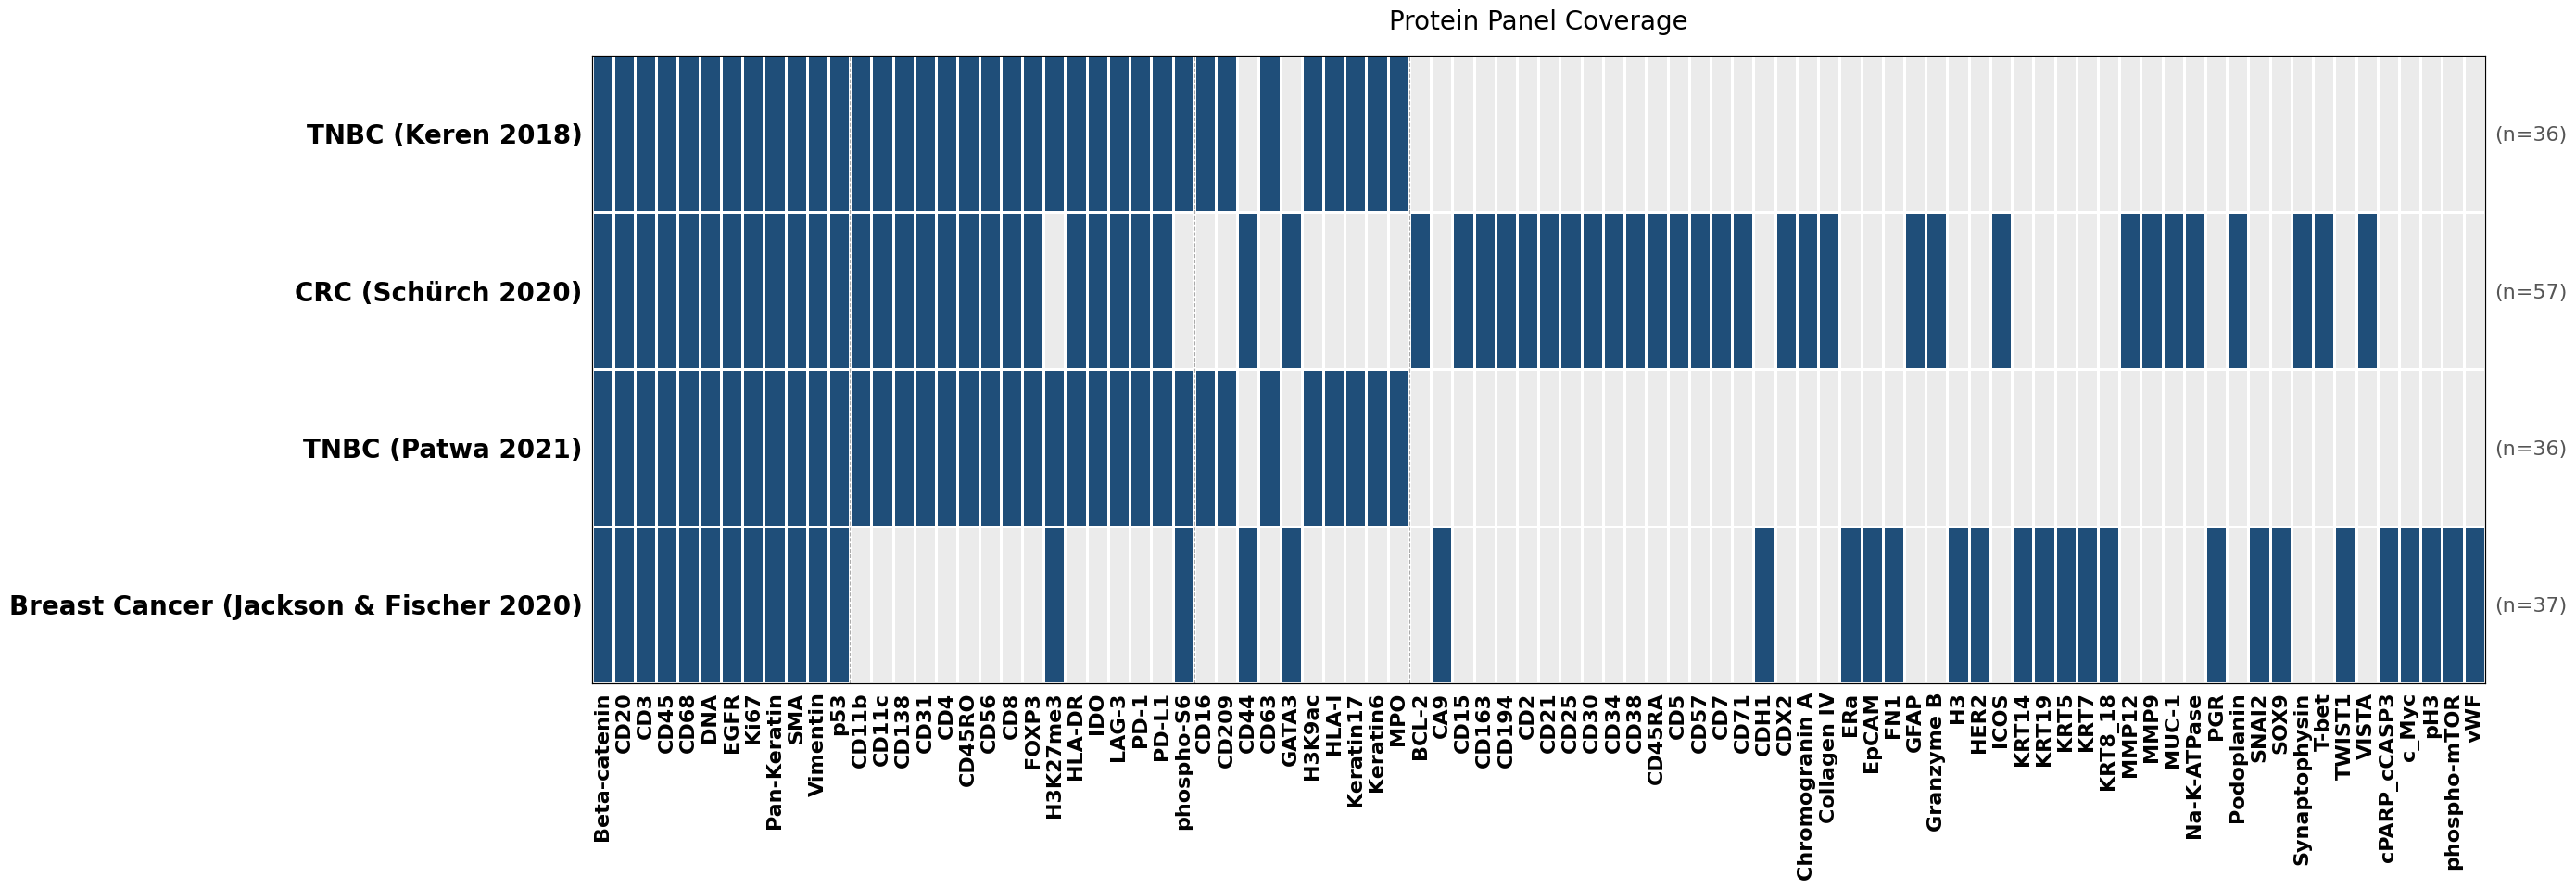

In [4]:
panel_heatmap(panels)

## Cell Type Coverage

Canonical cell type harmonization across the three datasets with curated annotations
(`CELLTYPE_ALIASES`). Ambiguous/artifact labels excluded. Jackson-Fischer omitted
(phenograph clusters, not named cell types).

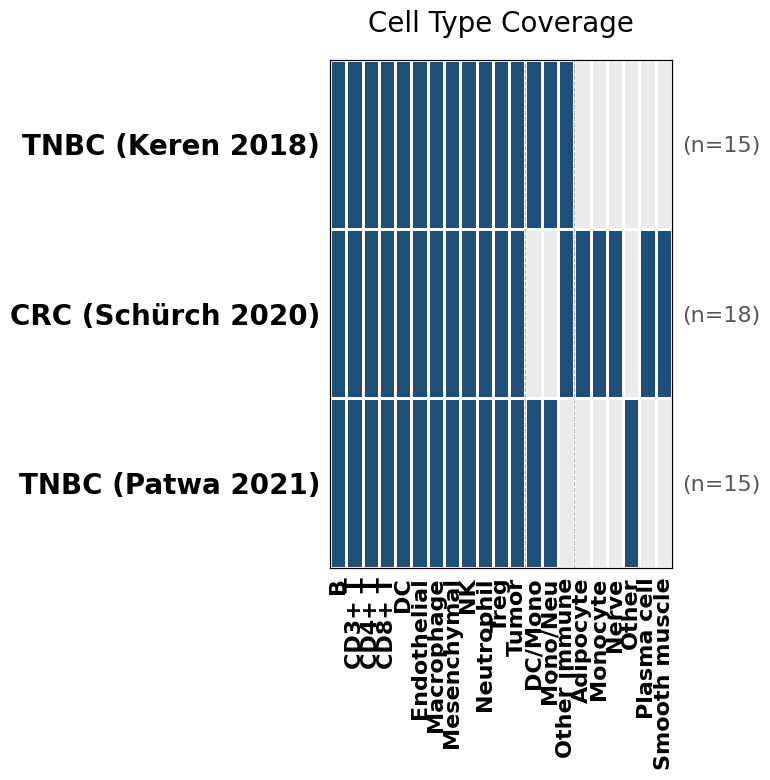

In [5]:
panel_heatmap(celltypes, title="Cell Type Coverage")

## Jackson-Fischer Cohort Breakdown

The Jackson-Fischer full object (used in modeling) is the union of two independently
acquired cohorts. Basel and Zurich share a common 45-marker schema, but Basel did not
measure EpCAM, β-catenin (CTNNB1), or SOX9 — those columns are NaN-filled in the
merged object. Marker counts below reflect the effective measured panel per cohort.

Publication,Technology,Disease,Condition,Patients,Samples,Cells,Markers
Jackson — Basel,IMC,Breast Cancer,HR+HER2+ / HR+HER2- / HR-HER2+ / TripleNeg,100,100,"285,851",34
Jackson — Zurich,IMC,Breast Cancer,HR+HER2+ / HR+HER2- / HR-HER2+ / TripleNeg,72,72,"104,919",37
Jackson — Full,IMC,Breast Cancer,HR+HER2+ / HR+HER2- / HR-HER2+ / TripleNeg,285,723,"1,240,267",37
Total,,,,457,895,"1,631,037",


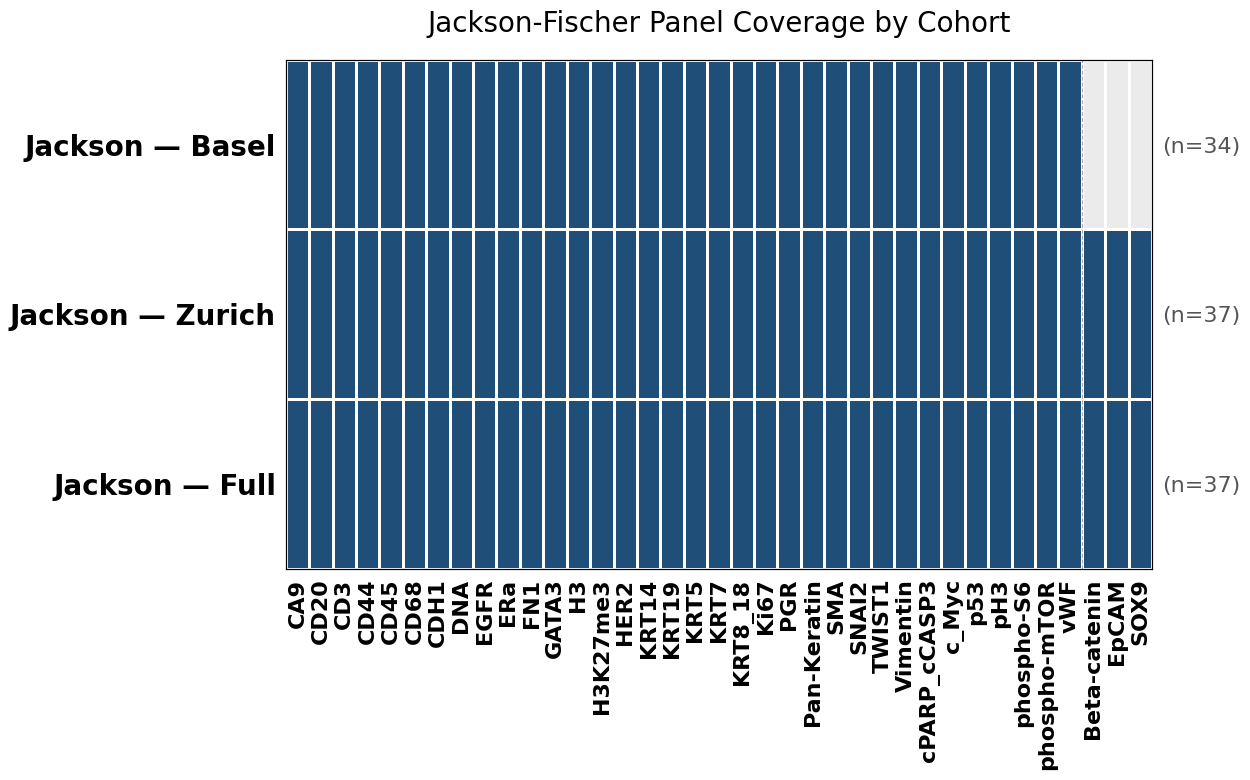

In [6]:
def _effective_panel(path):
    """Biological markers actually measured — drops technical channels and NaN-only columns."""
    a = ad.read_h5ad(path)
    L = a.layers["exprs"] if "exprs" in a.layers else a.X
    L = (L.toarray() if hasattr(L, "toarray") else np.asarray(L)).astype("float32")
    measured = [v for v, allnan in zip(a.var_names, np.isnan(L).all(axis=0)) if not allnan]
    return normalize_panel(measured)

JACKSON_COHORTS = [
    ("Jackson — Basel",  "../../../data/jacksonfischer2020/basel/basel.h5ad",  JACKSON_BASEL_CFG),
    ("Jackson — Zurich", "../../../data/jacksonfischer2020/zurich/zurich.h5ad", JACKSON_ZURICH_CFG),
    ("Jackson — Full",   "../../../data/jacksonfischer2020/full/full.h5ad",    JACKSON_CFG),
]

jackson_stats = []
jackson_panels = {}
for name, path, cfg in JACKSON_COHORTS:
    adata = ad.read_h5ad(path, backed="r")
    s = dataset_stats(adata, cfg)
    s["publication"] = name
    adata.file.close()
    ep = _effective_panel(path)
    s["n_markers"] = len(ep)
    jackson_stats.append(s)
    jackson_panels[name] = ep

overview_table(jackson_stats)
panel_heatmap(jackson_panels, title="Jackson-Fischer Panel Coverage by Cohort")